### Instructions for API extraction  (SKIP)

To start using the notebook:
1. Install dependencies in your .venv:

```
pip install -r requirements.txt
```

2. Go onto https://developer.company-information.service.gov.uk/manage-applications/add, create a new application and create a new key to obtain the API key
3. Create a file named ```.env``` and add your Companies House API key as ```CH_API_KEY=your_actual_api_key_here```. The block below will automatically import your API key, keeping it out of the source control

In [16]:
# import os
# from dotenv import load_dotenv

In [17]:
# # Load your .env API key
# load_dotenv()

# CH_API_KEY = os.getenv("CH_API_KEY")

# if not CH_API_KEY:
#     raise ValueError("CH_API_KEY not found. Check your .env file.")

### Instructions for bulk download

Go onto https://download.companieshouse.gov.uk/en_output.html and download the zipped file for Companies Records.

In [18]:
import pandas as pd

In [19]:
CSV_PATH = "../data/raw/BasicCompanyDataAsOneFile-2026-06-01.csv"

### EDA - Bulk Company Data

In [20]:
df_head = pd.read_csv(CSV_PATH, nrows=5)
df_head

,CompanyName,CompanyNumber,RegAddress.CareOf,RegAddress.POBox,RegAddress.AddressLine1,RegAddress.AddressLine2,RegAddress.PostTown,RegAddress.County,RegAddress.Country,RegAddress.PostCode,...,PreviousName_7.CONDATE,PreviousName_7.CompanyName,PreviousName_8.CONDATE,PreviousName_8.CompanyName,PreviousName_9.CONDATE,PreviousName_9.CompanyName,PreviousName_10.CONDATE,PreviousName_10.CompanyName,ConfStmtNextDueDate,ConfStmtLastMadeUpDate
0,! LTD,8209948,NaN,NaN,9 PRINCES SQUARE,NaN,HARROGATE,NaN,ENGLAND,HG1 1ND,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,25/09/2026,11/09/2025
1,!ABRIDGE TAX LTD,16092999,NaN,NaN,82 GREAT NORTH ROAD,GREAT NORTH BUSINESS CENTRE,HATFIELD,NaN,UNITED KINGDOM,AL9 5BL,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,04/12/2026,20/11/2025
2,!BIG IMPACT GRAPHICS LIMITED,11743365,NaN,NaN,124 CITY ROAD,NaN,LONDON,NaN,NaN,EC1V 2NX,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29/12/2026,15/12/2025
3,!FE NETWORK LIMITED,16873705,NaN,NaN,C/O AACSL ACCOUNTANT LIMITED,1ST FLOOR NORTH WESTGATE HOUSE,"HARLOW, ESSEX",NaN,UNITED KINGDOM,CM20 1YS,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,08/12/2026,NaN
4,!NFLECTION ADVISORY LIMITED,15073164,NaN,NaN,74 SANTERS LANE,NaN,POTTERS BAR,HERTFORDSHIRE,ENGLAND,EN6 2DA,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28/08/2026,14/08/2025


In [21]:
print(df_head.dtypes)

CompanyName                               str
 CompanyNumber                          int64
RegAddress.CareOf                     float64
RegAddress.POBox                      float64
RegAddress.AddressLine1                   str
 RegAddress.AddressLine2                  str
RegAddress.PostTown                       str
RegAddress.County                         str
RegAddress.Country                        str
RegAddress.PostCode                       str
CompanyCategory                           str
CompanyStatus                             str
CountryOfOrigin                           str
DissolutionDate                       float64
IncorporationDate                         str
Accounts.AccountRefDay                  int64
Accounts.AccountRefMonth                int64
Accounts.NextDueDate                      str
Accounts.LastMadeUpDate                   str
Accounts.AccountCategory                  str
Returns.NextDueDate                       str
Returns.LastMadeUpDate            

In [22]:
SAMPLE_N = 50_000
df = pd.read_csv(CSV_PATH, nrows=SAMPLE_N, low_memory=False)

date_cols = [
    "IncorporationDate", "DissolutionDate",
    "Accounts.NextDueDate", "Accounts.LastMadeUpDate",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

print(f"Shape: {df.shape}")
df.dtypes

Shape: (50000, 55)


CompanyName                                      str
 CompanyNumber                                   str
RegAddress.CareOf                                str
RegAddress.POBox                                 str
RegAddress.AddressLine1                          str
 RegAddress.AddressLine2                         str
RegAddress.PostTown                              str
RegAddress.County                                str
RegAddress.Country                               str
RegAddress.PostCode                              str
CompanyCategory                                  str
CompanyStatus                                    str
CountryOfOrigin                                  str
DissolutionDate                        datetime64[s]
IncorporationDate                     datetime64[us]
Accounts.AccountRefDay                       float64
Accounts.AccountRefMonth                     float64
Accounts.NextDueDate                  datetime64[us]
Accounts.LastMadeUpDate               datetime

In [23]:
null_summary = df.isnull().sum().rename("null_count").to_frame()
null_summary["null_pct"] = (null_summary["null_count"] / len(df) * 100).round(1)
null_summary.sort_values("null_pct", ascending=False)

,null_count,null_pct
DissolutionDate,50000,100.0
PreviousName_9.CONDATE,49998,100.0
PreviousName_9.CompanyName,49998,100.0
PreviousName_7.CONDATE,49997,100.0
PreviousName_7.CompanyName,49997,100.0
PreviousName_8.CompanyName,49997,100.0
PreviousName_8.CONDATE,49997,100.0
PreviousName_10.CONDATE,49999,100.0
PreviousName_10.CompanyName,49999,100.0
PreviousName_6.CompanyName,49995,100.0


In [24]:
for col in ["CompanyCategory", "CompanyStatus", "CountryOfOrigin", "Accounts.AccountCategory"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(15))


--- CompanyCategory ---
CompanyCategory
Private Limited Company                                                                      41321
PRI/LTD BY GUAR/NSC (Private, limited by guarantee, no share capital)                         7423
Overseas Entity                                                                                285
Limited Liability Partnership                                                                  257
Limited Partnership                                                                            212
Community Interest Company                                                                     176
Charitable Incorporated Organisation                                                            88
Other company type                                                                              67
PRI/LBG/NSC (Private, Limited by guarantee, no share capital, use of 'Limited' exemption)       61
Public Limited Company                                              

In [25]:
df.select_dtypes("number").describe()

,Accounts.AccountRefDay,Accounts.AccountRefMonth,Mortgages.NumMortCharges,Mortgages.NumMortOutstanding,Mortgages.NumMortPartSatisfied,Mortgages.NumMortSatisfied,LimitedPartnerships.NumGenPartners,LimitedPartnerships.NumLimPartners
count,49362.000000,49362.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.00000,50000.00000
mean,30.120903,6.457093,0.373500,0.213940,0.000340,0.15896,0.00440,0.01618
std,2.723617,3.599018,3.824815,1.190864,0.020491,3.52081,0.07029,0.61156
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
25%,30.000000,3.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
50%,31.000000,6.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
75%,31.000000,10.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.00000
max,31.000000,12.000000,718.000000,96.000000,2.000000,718.00000,3.00000,72.00000


In [26]:
df["SICCode.SicText_1"].value_counts().head(20)

SICCode.SicText_1
98000 - Residents property management                                        15113
68209 - Other letting and operating of own or leased real estate              4334
68100 - Buying and selling of own real estate                                 2799
68320 - Management of real estate on a fee or contract basis                  2094
99999 - Dormant Company                                                       1205
None Supplied                                                                 1153
82990 - Other business support service activities n.e.c.                      1086
70229 - Management consultancy activities other than financial management     1076
96090 - Other service activities n.e.c.                                        837
41100 - Development of building projects                                       804
62020 - Information technology consultancy activities                          753
74990 - Non-trading company                                          

<Axes: title={'center': 'Incorporations by Year'}, xlabel='IncorporationDate'>

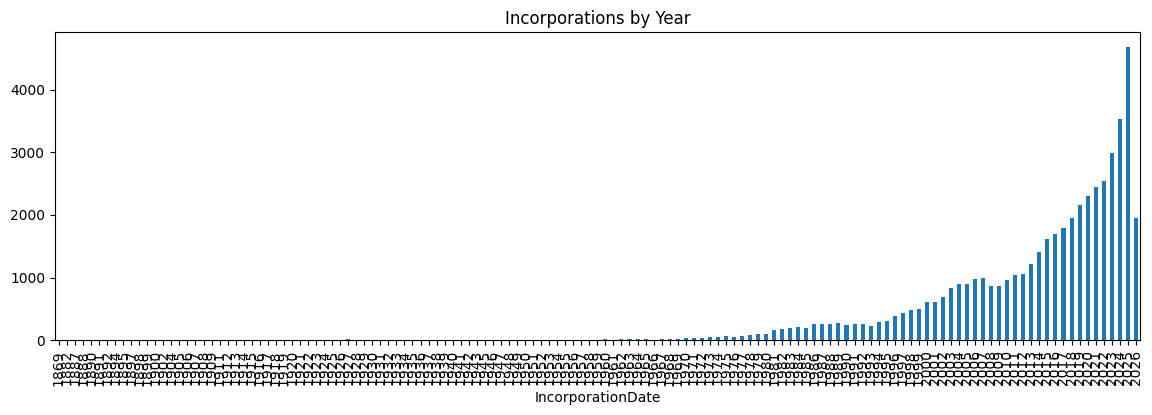

In [29]:
df["IncorporationDate"].dt.year.value_counts().sort_index().plot(
    kind="bar", figsize=(14, 4), title="Incorporations by Year"
)

<Axes: title={'center': 'Company Status Distribution'}, xlabel='CompanyStatus'>

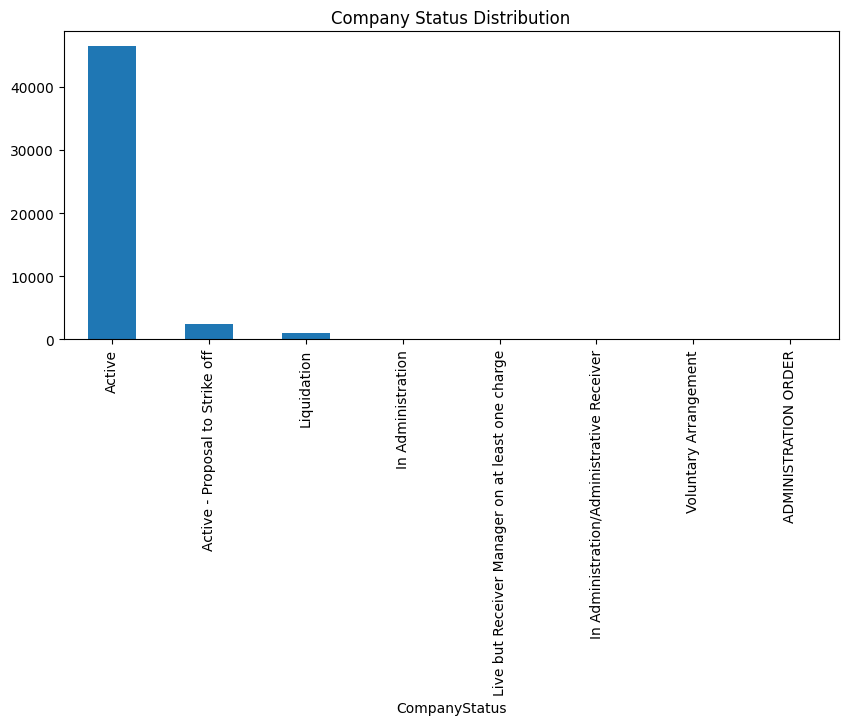

In [30]:
df["CompanyStatus"].value_counts().plot(
    kind="bar", figsize=(10, 4), title="Company Status Distribution"
)